In [2]:
# Import the library
from hgboost import hgboost

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from skopt import BayesSearchCV
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

In [4]:
# Preparing the data
df = pd.read_csv('df_train.csv')
df.drop(['Unnamed: 0'], axis=1, inplace=True)

# reading test data
df_test = pd.read_csv('df_test.csv')
df_test.drop('Unnamed: 0', axis=1, inplace=True)

df

,N,xm,nr,ni,p1,p2,p3
0,7,0.640,1.71,0.045,1.685110,-0.001577,-0.009044
1,10,0.336,1.30,0.023,2.235463,-0.096444,-0.104801
2,6,0.640,1.30,0.023,0.339716,-0.000123,-0.002486
3,7,0.480,1.30,0.023,0.618308,-0.000189,-0.001309
4,8,0.530,1.80,0.023,1.429310,-0.007968,-0.013564
...,...,...,...,...,...,...,...
210,9,0.479,1.45,0.023,3.861650,-0.113987,-0.158734
211,8,0.960,1.30,0.023,6.662236,-0.206193,-0.104666
212,8,0.960,2.00,0.090,14.004366,-0.546805,-0.380360
213,7,0.440,1.66,0.086,0.860949,-0.000236,-0.001893


In [109]:
# from bhmie import *

# data = pd.read_csv('allregimes.csv')

# def calc_tau(N, xm, nr, ni):
#     N = 2**N
#     s1,s2,qext,qsca,qback,gsca = bhmie(xm,complex(nr, ni),91)
#     csca_mon = qsca * np.pi * xm**2
#     cext_mon = qext * np.pi * xm**2
#     cabs_mon = (qext - qsca) * np.pi * xm**2

#     R1 = 1.598
#     Rcut = 1. / 0.0001
#     Df = 2.0
#     Rmin=2.0
#     #dstep = 1/(8*xm)
#     ds = 1/(8*xm)
#     Rmax = R1*(N*np.log(Rcut))**(1.0/Df)
#     nstep = int((Rmax - Rmin) /ds)
#     nstep = np.where(nstep < 100, 100, nstep)
#     dstep = (Rmax - Rmin)/(nstep-1)

#     R0 = np.arange(nstep)*dstep + Rmin
#     dist = R0 * xm
#     nc = ((1.0 - np.exp(-(R0/R1)**(Df) /N))*(1.0 - np.exp(-(R0/3.478)**3.194)) + (2.0/N) )/(1 + (2.0/N))
#     #nc=1.0 - np.exp(-(R0/R1)**(Df) /N)
#     f0 = np.zeros(nstep)
#     f0[0] = 0.5 * (nc[1]-nc[0]) + nc[0] # this seems to include nc[0] erronously
#     #f0[0] = 0.5 * (nc[1]-nc[0])
#     f0[nstep-1] =  1. - nc[nstep-1] + 0.5 * (nc[nstep-1]-nc[nstep-2])
#     #f0[nstep-1] = 0.5 * (nc[nstep-1]-nc[nstep-2]) #
#     f0[1:(nstep-1)] =  (nc[2:(nstep)] - nc[0:(nstep-2)])/(2)
#     tau_coef = np.sum(f0 / dist**2) / 4. / np.pi * (N-1)
#     taue_out = tau_coef * cext_mon
#     taus_out = tau_coef * csca_mon
#     taua_out = tau_coef * cabs_mon
#     return taus_out, taua_out


In [114]:
# tau_new = df_test.apply(lambda row: pd.Series(calc_tau(row['N'], row['xm'], row['nr'], row['ni'])), axis=1).values
# taus_out = tau_new[:,0]
# taua_out = tau_new[:,1]
# df_test[['taus_out', 'taua_out']] = tau_new

#### Modelling Strategy
For each observation there are three response variables. The response variables, p1, p2, p3 are ceofficients of a legendre polynomial describing the same curve of a phase function that corresponds to an aerosol particle with features N, xm, nr, ni. Therefore each response variable depend on the features as well as each other. Finally the relationship between the the features and response variable may not be linear.

Based on these properties of the data using a tree based algorithm I will first model p1 using the features in the data 

# Step 1 Modelling P1

In [5]:
# For p1 do not use any p columns as predictor 
X = df.drop(columns=['p1', 'p2', 'p3'])
y1 = df['p1'].values

X_test = df_test.drop(columns=['p1', 'p2', 'p3'])
y_test1 = df_test['p1']

In [6]:
# Define the search space for hyperparameters
params = {
    'learning_rate': (0.0005, 1.0, 'log-uniform'),
    'n_estimators': (10, 5000),
    'max_depth': (1, 50),
    'min_child_weight': (1, 10),
    'subsample': (0.1, 1.0, 'uniform'),
    'colsample_bytree': (0.1, 1.0, 'uniform')
}

# Define the XGBoost regression model
xgb = XGBRegressor()

In [7]:
# Define the BayesSearchCV object for hyperparameter tuning
bayes_cv1 = BayesSearchCV(
    estimator=xgb,
    search_spaces=params,
    cv=4,
    n_iter=350,
    n_jobs=-1,
    verbose=0
)

# Fit the BayesSearchCV object to the training data
bayes_cv1.fit(X, y1)


<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scip

BayesSearchCV(cv=4,
              estimator=XGBRegressor(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     n_estimators=100, n_jobs=None,
                        

In [8]:
# Print the best set of hyperparameters found by the optimization algorithm
print("Best hyperparameters: ", bayes_cv1.best_params_)


Best hyperparameters:  OrderedDict([('colsample_bytree', 1.0), ('learning_rate', 0.015007653687992582), ('max_depth', 50), ('min_child_weight', 1), ('n_estimators', 4175), ('subsample', 0.22315856869214523)])


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluate the performance of the best model on the test set
y_pred = bayes_cv1.predict(X_test)
mae = mean_absolute_error(y_test1, y_pred)
rmse = mean_squared_error(y_test1, y_pred, squared=False)
r2 = r2_score(y_test1, y_pred)

print("Mean Absolute Error: {:.3f}".format(mae))
print("Root Mean Squared Error: {:.3f}".format(rmse))
print("R-squared Score: {:.3f}".format(r2))

Mean Absolute Error: 0.331
Root Mean Squared Error: 0.676
R-squared Score: 0.975


In [10]:
# Save the best model to disk
import joblib
joblib.dump(bayes_cv1.best_estimator_, 'xgb_model_p1_no_augmented_dt.joblib')

['xgb_model_p1_no_augmented_dt.joblib']

## Second model - P2
For model P2 we use the standard features and p1 as predictor

In [20]:
# 
X2 = df.drop(columns=['p2', 'p3'])
X_test2 = df_test.drop(columns=['p2', 'p3'])

y2 = df['p2'].values
y_test2 = df_test['p2']

In [21]:
# Define the BayesSearchCV object for hyperparameter tuning
bayes_cv2 = BayesSearchCV(
    estimator=xgb,
    search_spaces=params,
    cv=3,
    n_iter=400,
    n_jobs=-1,
    verbose=1
)

# Fit the BayesSearchCV object to the training data
bayes_cv2.fit(X2, y2 )

Fitting 3 folds for each of 1 candidates, totalling 3 fits


<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Fitting 3 folds for each of 1 candidates, totalling 3 fits


<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Fitting 3 folds for each of 1 candidates, totalling 3 fits


...

Fitting 3 folds for each of 1 candidates, totalling 3 fits


<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Fitting 3 folds for each of 1 candidates, totalling 3 fits


<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


BayesSearchCV(cv=3,
              estimator=XGBRegressor(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     missing=nan, monotone_constraints=None,
                                     n_estimators=100, n_jobs=None,
                                     num_parallel_tree=None, predictor=None,
                        

In [22]:
# Print the best set of hyperparameters found by the optimization algorithm
print("Best hyperparameters: ", bayes_cv2.best_params_)


Best hyperparameters:  OrderedDict([('colsample_bytree', 0.8967817555202745), ('learning_rate', 0.03301188755935444), ('max_depth', 3), ('min_child_weight', 2), ('n_estimators', 3448), ('subsample', 0.4470380511154235)])


In [23]:
joblib.dump(bayes_cv1.best_estimator_, 'xgb_model_p2_no_augmented_dt.joblib')

['xgb_model_p2_no_augmented_dt.joblib']

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluate the performance of the best model on the test set
y_pred2 = bayes_cv2.predict(X_test2)
mae = mean_absolute_error(y_test2, y_pred2)
rmse = mean_squared_error(y_test2, y_pred2, squared=False)
r2 = r2_score(y_test2, y_pred2)

print("Mean Absolute Error: {:.3f}".format(mae))
print("Root Mean Squared Error: {:.3f}".format(rmse))
print("R-squared Score: {:.3f}".format(r2))

Mean Absolute Error: 0.080
Root Mean Squared Error: 0.235
R-squared Score: 0.801


# Third Model - P3
For P3 we use standard features plus P1 and P2 as predictors

In [25]:
# Dropping only P3 leaves p1 and p2 among the predictors
X3 = df.drop(columns=['p3'])
X_test3 = df_test.drop(columns=['p3'])

y3 = df['p3'].values
y_test3 = df_test['p3']

# Define the BayesSearchCV object for hyperparameter tuning
bayes_cv3 = BayesSearchCV(
    estimator=xgb,
    search_spaces=params,
    cv=3,
    n_iter=500,
    n_jobs=-1,
    verbose=0
)

# Fit the BayesSearchCV object to the training data
bayes_cv3.fit(X3, y3 )

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scip

BayesSearchCV(cv=3,
              estimator=XGBRegressor(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     n_estimators=100, n_jobs=None,
                        

In [26]:
# Print the best set of hyperparameters found by the optimization algorithm
print("Best hyperparameters: ", bayes_cv3.best_params_)


Best hyperparameters:  OrderedDict([('colsample_bytree', 0.6608253438944415), ('learning_rate', 0.04324604324570002), ('max_depth', 36), ('min_child_weight', 3), ('n_estimators', 3888), ('subsample', 0.5952966426938598)])


['xgb_model_p3_no_augmented_dt.joblib']

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluate the performance of the best model on the test set
y_pred3 = bayes_cv3.predict(X_test3)
mae = mean_absolute_error(y_test3, y_pred3)
rmse = mean_squared_error(y_test3, y_pred3, squared=False)
r2 = r2_score(y_test3, y_pred3)

print("Mean Absolute Error: {:.3f}".format(mae))
print("Root Mean Squared Error: {:.3f}".format(rmse))
print("R-squared Score: {:.3f}".format(r2))

Mean Absolute Error: 0.009
Root Mean Squared Error: 0.014
R-squared Score: 0.993


In [ ]:
joblib.dump(bayes_cv1.best_estimator_, 'xgb_model_p3_no_augmented_dt.joblib')

In [30]:
df.query('N >=8')

,N,xm,nr,ni,p1,p2,p3
1,10,0.336,1.30,0.023,2.235463,-0.096444,-0.104801
4,8,0.530,1.80,0.023,1.429310,-0.007968,-0.013564
5,8,0.960,1.68,0.023,8.327186,-0.340593,-0.204285
6,8,0.336,1.68,0.045,0.555090,-0.000600,-0.002254
8,8,0.832,1.68,0.023,5.369442,-0.135053,-0.106187
...,...,...,...,...,...,...,...
209,9,0.640,2.00,0.090,10.726278,-0.658814,-0.478979
210,9,0.479,1.45,0.023,3.861650,-0.113987,-0.158734
211,8,0.960,1.30,0.023,6.662236,-0.206193,-0.104666
212,8,0.960,2.00,0.090,14.004366,-0.546805,-0.380360


# Training with Slightly augmented data $N >= 256$

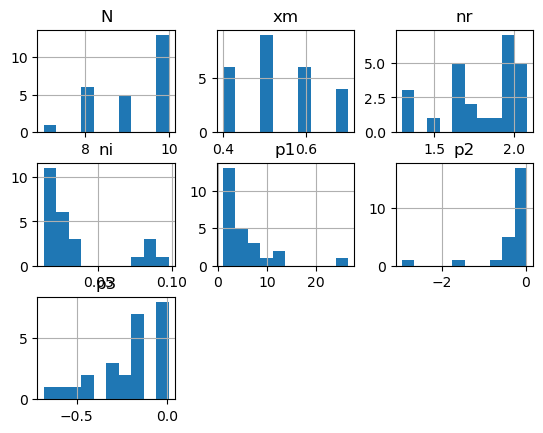

In [77]:
synthetic_data = pd.read_csv('best_X_weighted_distr.csv')
synthetic_data.drop(columns=['Unnamed: 0'], inplace=True)
synthetic_data = synthetic_data.sample(25)
_ = synthetic_data.hist()

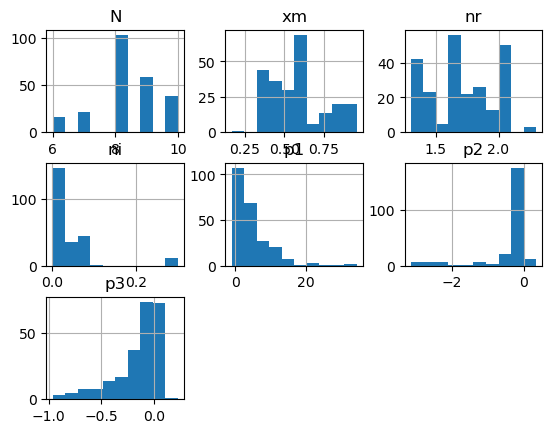

In [78]:
df_augmented = pd.concat([df, synthetic_data])
_ = df_augmented.hist()

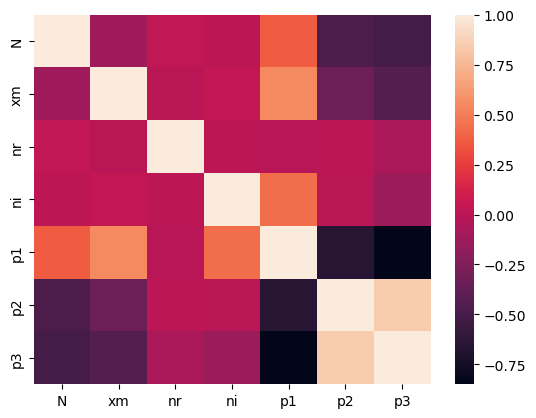

In [98]:
_ = sns.set_palette('Blues')
_ = sns.heatmap(df.corr())
plt.show()

## P1

In [93]:
# # For p1 do not use any p columns as predictor
# df = df_augmented
# df_test_256 = df_test.query('N >= 8')

X_aug = df_augmented.drop(columns=['p1', 'p2', 'p3'])
y1_aug = df_augmented['p1'].values

X_aug_test = df_test.drop(columns=['p1', 'p2', 'p3'])
y_aug_test1 = df_test['p1']
# Define the BayesSearchCV object for hyperparameter tuning
bayes_cv1_aug = BayesSearchCV(
    estimator=xgb,
    search_spaces=params,
    cv=4,
    n_iter=550,
    n_jobs=-1,
    verbose=0
)

# Fit the BayesSearchCV object to the training data
bayes_cv1_aug.fit(X_aug, y1_aug,)

# Print the best set of hyperparameters found by the optimization algorithm
print("Best hyperparameters: ", bayes_cv1_aug.best_params_)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluate the performance of the best model on the test set
y_pred_1_aug = bayes_cv1_aug.predict(X_aug_test)
mae = mean_absolute_error(y_aug_test1, y_pred_1_aug)
rmse = mean_squared_error(y_aug_test1, y_pred_1_aug, squared=False)
r2 = r2_score(y_aug_test1, y_pred_1_aug)

print("Mean Absolute Error: {:.3f}".format(mae))
print("Root Mean Squared Error: {:.3f}".format(rmse))
print("R-squared Score: {:.3f}".format(r2))


<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scip

Best hyperparameters:  OrderedDict([('colsample_bytree', 0.9714963159519555), ('learning_rate', 0.06811951886664495), ('max_depth', 45), ('min_child_weight', 1), ('n_estimators', 1089), ('subsample', 0.6022127208305197)])
Mean Absolute Error: 0.570
Root Mean Squared Error: 1.029
R-squared Score: 0.942


In [94]:
# Save the best model to disk
joblib.dump(bayes_cv1_aug.best_estimator_, 'Xgb_model_p1_lite_augmented_dt.joblib')

['Xgb_model_p1_lite_augmented_dt.joblib']

## P2 model

In [89]:
X_aug_2 = df_augmented.drop(columns=[ 'p2', 'p3'])
y_aug_2 = df_augmented['p2'].values

X_aug_test_2 = df_test.drop(columns=['p2', 'p3'])
y_aug_test_2 = df_test['p2']
# Define the BayesSearchCV object for hyperparameter tuning
bayes_cv2_aug = BayesSearchCV(
    estimator=xgb,
    search_spaces=params,
    cv=4,
    n_iter=350,
    n_jobs=-1,
    verbose=0
)

# Fit the BayesSearchCV object to the training data
bayes_cv2_aug.fit(X_aug_2, y_aug_2)

# Print the best set of hyperparameters found by the optimization algorithm
print("Best hyperparameters: ", bayes_cv2_aug.best_params_)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluate the performance of the best model on the test set
y_pred_aug_2 = bayes_cv2_aug.predict(X_aug_test_2)
mae = mean_absolute_error(y_aug_test_2, y_pred_aug_2)
rmse = mean_squared_error(y_aug_test_2, y_pred_aug_2, squared=False)
r2 = r2_score(y_aug_test_2, y_pred_aug_2)

print("Mean Absolute Error: {:.3f}".format(mae))
print("Root Mean Squared Error: {:.3f}".format(rmse))
print("R-squared Score: {:.3f}".format(r2))


<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scip

Best hyperparameters:  OrderedDict([('colsample_bytree', 0.9097154014813412), ('learning_rate', 0.018449715061954402), ('max_depth', 14), ('min_child_weight', 2), ('n_estimators', 3428), ('subsample', 0.2535160970159112)])
Mean Absolute Error: 0.084
Root Mean Squared Error: 0.234
R-squared Score: 0.803


In [90]:
# Save the best model to disk
joblib.dump(bayes_cv2_aug.best_estimator_, 'Xgb_model_p2_lite_augmented_dt.joblib')

['Xgb_model_p2_lite_augmented_dt.joblib']

## $P_3$ MODEL

In [91]:
X_aug_3 = df_augmented.drop(columns=[ 'p3'])
y_aug_3 = df_augmented['p3'].values

X_aug_test_3 = df_test.drop(columns=['p3'])
y_aug_test_3 = df_test['p3']
# Define the BayesSearchCV object for hyperparameter tuning
bayes_cv3_aug = BayesSearchCV(
    estimator=xgb,
    search_spaces=params,
    cv=4,
    n_iter=300,
    n_jobs=-1,
    verbose=0
)

# Fit the BayesSearchCV object to the training data
bayes_cv3_aug.fit(X_aug_3, y_aug_3)

# Print the best set of hyperparameters found by the optimization algorithm
print("Best hyperparameters: ", bayes_cv3_aug.best_params_)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluate the performance of the best model on the test set
y_pred_aug_3 = bayes_cv3_aug.predict(X_aug_test_3)
mae = mean_absolute_error(y_aug_test_3, y_pred_aug_3)
rmse = mean_squared_error(y_aug_test_3, y_pred_aug_3, squared=False)
r2 = r2_score(y_aug_test_3, y_pred_aug_3)

print("Mean Absolute Error: {:.3f}".format(mae))
print("Root Mean Squared Error: {:.3f}".format(rmse))
print("R-squared Score: {:.3f}".format(r2))


Best hyperparameters:  OrderedDict([('colsample_bytree', 0.9900317443635012), ('learning_rate', 0.004119769383370469), ('max_depth', 47), ('min_child_weight', 2), ('n_estimators', 2783), ('subsample', 0.6435739488245824)])
Mean Absolute Error: 0.009
Root Mean Squared Error: 0.017
R-squared Score: 0.991


In [92]:
# Save the best model to disk
joblib.dump(bayes_cv3_aug.best_estimator_, 'Xgb_model_p3_lite_augmented_dt.joblib')

['Xgb_model_p3_lite_augmented_dt.joblib']